# Фінальне рішення: від сирих даних до `submission.csv`

**Змагання:** [Deep Learning for CV and NLP 2026-10](https://www.kaggle.com/competitions/deep-learning-for-computer-vision-and-nlp-2026-10)
(урізаний PetFinder.my: тільки опис і фото → `AdoptionSpeed` 1–4, метрика QWK).

Цей ноутбук **самодостатній**: він стартує з `data/raw/{train,test}.csv` і `data/raw/images/`,
виконує всі етапи рішення із зафіксованими параметрами і записує `submissions/submission.csv`.
Ноутбуки `01`–`07` — це дослідницька частина (аналіз, абляції, вибір параметрів);
тут — лише фінальний конвеєр. Код етапів — у `src/pipeline.py` та модулях `src/`.

**Схема рішення:**

```
опис ─┬─ regex / мета-ознаки, kNN-target по TF-IDF ──────────────┐
      ├─ Ridge(TF-IDF), DeBERTa-v3-base (fine-tune) ──────────────┤
      └─ Ridge(CLIP текст), Ridge(SigLIP2 текст) ─────────────────┤
фото ─┬─ CLIP ViT-L/14: zero-shot, якість, kNN-target, текст↔фото ─┤──► LightGBM (2-й рівень, 5 сідів)
      ├─ SigLIP2 SO400M: те саме ──────────────────────────────────┤      → пороги OptimizedRounder
      ├─ Ridge(CLIP фото), Ridge(SigLIP2 фото) ────────────────────┤      → refit на всьому train
      └─ attention-голова на ембедінгах усіх фото ─────────────────┘      → submission.csv
```

Усі target-залежні входи (kNN-target, моделі 1-го рівня) пораховані **out-of-fold** на одних і тих самих
5 стратифікованих фолдах.

**Час:** ~45 хв з нуля на RTX 4080 Laptop (12 GB): CLIP ~5 хв, SigLIP2 ~13 хв, DeBERTa ~18 хв.
Ембедінги фото й передбачення DeBERTa кешуються в `data/final_cache/` —
повторний запуск займає кілька хвилин. `USE_CACHE = False` — перерахувати все.

In [1]:
import sys
import time
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from src.config import ID_COL, TARGET_COL
from src.utils import seed_everything, write_submission
from src.pipeline import (FinalConfig, LEVEL1_NAMES, prepare_data, text_features, clip_features,
                          siglip_features, ridge_models, deberta_model, attention_head_model,
                          level2_stack, oof_qwk)

USE_CACHE = True
cfg = FinalConfig(use_cache=USE_CACHE)
seed_everything(cfg.seed)
sns.set_theme(style="whitegrid")
timings = {}
print("device:", cfg.device, torch.cuda.get_device_name(0) if cfg.device == "cuda" else "")

device: cuda NVIDIA GeForce RTX 4080 Laptop GPU


In [2]:
# All fixed parameters of the final solution
pd.Series({k: v for k, v in cfg.__dict__.items()}).to_frame("значення")

,значення
seed,42
n_folds,5
cache_dir,C:\Users\pbori\Documents\Courses\Neoversity\De...
use_cache,True
device,cuda
text_dup_threshold,0.9
clip_model,ViT-L-14
clip_pretrained,datacomp_xl_s13b_b90k
clip_logit_scale,100.0
img_dup_threshold,0.95


## 1. Дані та фолди

`PetID` читаються як рядки; 4 ID з test.csv, що втратили ведучий нуль, доповнюються до 9 символів
для пошуку фото (у сабмішні вони повертаються у вихідному вигляді). Фолди — `StratifiedKFold(5, seed=42)`.

In [3]:
t0 = time.time()
train, test, img_index = prepare_data(cfg)
y, n_tr = train[TARGET_COL].to_numpy(float), len(train)
timings["дані"] = time.time() - t0
print(f"train {train.shape}, test {test.shape}, images {len(img_index)}")
print("pets without photos — train:", (train["n_photos"] == 0).sum(), " test:", (test["n_photos"] == 0).sum())
train["fold"].value_counts().sort_index().to_dict()

train (6431, 5), test (1891, 3), images 37920
pets without photos — train: 0  test: 0


{0: 1287, 1: 1286, 2: 1286, 3: 1286, 4: 1286}

## 2. Ознаки з тексту

Мета-статистики, regex (тип, вік у місяцях, порода, здоров'я, внесок, мова…), OOF kNN-target по
char TF-IDF (майже-дублікати оголошень мають майже однаковий таргет), розмір групи дублікатів.

In [4]:
t0 = time.time()
text_f = text_features(train, test, cfg)
timings["ознаки тексту"] = time.time() - t0
print(text_f.shape)

(8322, 40)


## 3. Ознаки з фото: CLIP ViT-L/14 і SigLIP2 SO400M

Для кожного енкодера: ембедінги всіх фото → zero-shot ймовірності (вік, порода, кількість тварин,
обстановка, якість…) з агрегацією first / mean / max по тварині, OOF kNN-target по ембедінгах,
схожість опису та фото. Для CLIP — ще прості метрики якості фото та розмір групи дублікатів.

In [5]:
t0 = time.time()
clip_f, clip_embs = clip_features(img_index, train, test, cfg)
timings["CLIP"] = time.time() - t0
t0 = time.time()
siglip_f, siglip_embs = siglip_features(img_index, train, test, cfg)
timings["SigLIP2"] = time.time() - t0
print("CLIP features:", clip_f.shape, "  SigLIP2 features:", siglip_f.shape)

images:   0%|          | 0/297 [00:11<?, ?it/s]

images:   0%|          | 0/593 [00:12<?, ?it/s]

C:\Users\pbori\Documents\Courses\Neoversity\DeepL\neoversity-dl-cv-final\src\images.py:253: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  zs = zero_shot_features(img_emb, model, tokenizer, device, logit_scale=float(model.logit_scale.exp()))


CLIP features: (8322, 115)   SigLIP2 features: (8322, 90)


## 4. Моделі 1-го рівня (OOF-передбачення)

- Ridge на «сирих» представленнях: CLIP / SigLIP2 фото (середнє + перше фото), TF-IDF, CLIP / SigLIP2 текст;
- DeBERTa-v3-base, fine-tuning на регресію (3 епохи, найкращий чекпойнт за val RMSE);
- attention-голова на ембедінгах усіх фото (CLIP ⊕ SigLIP2, до 12 фото, 7 епох × 5 сідів).

In [6]:
t0 = time.time()
level1 = ridge_models(train, test, clip_embs, siglip_embs, cfg)
timings["Ridge ×5"] = time.time() - t0

t0 = time.time()
level1["text_deberta"] = deberta_model(train, test, cfg)
timings["DeBERTa"] = time.time() - t0

t0 = time.time()
level1["head_img"] = attention_head_model(img_index, train, test, clip_embs, siglip_embs, cfg)
timings["attention-голова"] = time.time() - t0

level1 = level1[list(LEVEL1_NAMES)]
pd.DataFrame({"модель": LEVEL1_NAMES.values(),
              "OOF QWK": [oof_qwk(y, level1[k].to_numpy()[:n_tr]) for k in LEVEL1_NAMES]}).round(4)

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


fold 0: best val rmse 1.0586  fold QWK 0.3786  (4.3 min)


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

fold 3: best val rmse 1.0719  fold QWK 0.3722  (4.2 min)


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


fold 4: best val rmse 1.0402  fold QWK 0.3819  (4.3 min)


,модель,OOF QWK
0,Ridge · CLIP фото,0.5871
1,Ridge · SigLIP2 фото,0.5997
2,Attention-голова · фото,0.6112
3,Ridge · TF-IDF,0.3350
4,Ridge · CLIP текст,0.2813
5,Ridge · SigLIP2 текст,0.2925
6,DeBERTa-v3-base,0.3494


## 5. Модель 2-го рівня: LightGBM на ознаках + OOF моделей 1-го рівня

5 сідів, пороги `OptimizedRounder` на OOF. «Чесна» оцінка — пороги підбираються на 4 фолдах
і застосовуються до 5-го. Фінальна модель перенавчається на всьому train
(кількість раундів = середнє з CV × 1.15).

In [7]:
t0 = time.time()
n_photos = pd.concat([train[["n_photos"]], test[["n_photos"]]], ignore_index=True)
X = pd.concat([n_photos, text_f, clip_f, siglip_f, level1], axis=1)
stack = level2_stack(X, train, cfg)
timings["стекінг"] = time.time() - t0

print("features:", X.shape[1])
print("per-seed OOF QWK:", np.round(stack["seed_qwk"], 4))
print(f"OOF QWK (5 seeds):          {stack['qwk']:.4f}")
print(f"honest OOF QWK:             {stack['qwk_honest']:.4f}")
print("thresholds:", stack["rounder"].coef_.round(3), "  refit rounds:", stack["n_rounds"])

features: 253
per-seed OOF QWK: [0.6221 0.6199 0.6215 0.6187 0.6208]
OOF QWK (5 seeds):          0.6243
honest OOF QWK:             0.6194
thresholds: [1.973 2.503 3.338]   refit rounds: 459


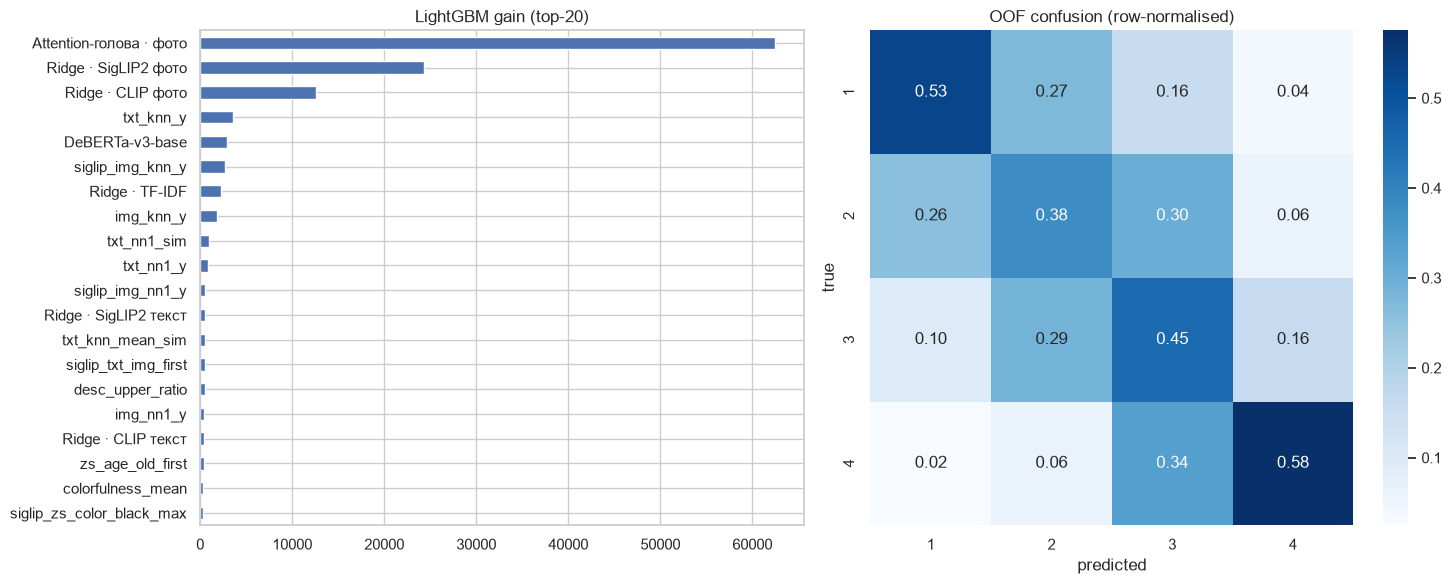

In [8]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
stack["importance"].rename(index=LEVEL1_NAMES).sort_values(ascending=False).head(20).plot.barh(
    ax=axes[0], title="LightGBM gain (top-20)").invert_yaxis()
cm = confusion_matrix(y, stack["rounder"].predict(stack["oof"]), labels=[1, 2, 3, 4], normalize="true")
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", xticklabels=[1, 2, 3, 4], yticklabels=[1, 2, 3, 4], ax=axes[1])
axes[1].set(xlabel="predicted", ylabel="true", title="OOF confusion (row-normalised)")
plt.tight_layout();

## 6. Сабмішн

In [9]:
pred_cls = stack["rounder"].predict(stack["test"])
display(pd.DataFrame({
    "train (true)": pd.Series(y).value_counts(normalize=True),
    "OOF (pred)": pd.Series(stack["rounder"].predict(stack["oof"])).value_counts(normalize=True),
    "test (pred)": pd.Series(pred_cls).value_counts(normalize=True),
}).sort_index().round(3))
path = write_submission(test[ID_COL], pred_cls, "submission")
pd.read_csv(path, dtype=str).head()

,train (true),OOF (pred),test (pred)
1.0,0.186,0.199,0.206
2.0,0.276,0.236,0.212
3.0,0.206,0.317,0.284
4.0,0.332,0.248,0.298


Saved C:\Users\pbori\Documents\Courses\Neoversity\DeepL\neoversity-dl-cv-final\submissions\submission.csv  shape=(1891, 2)
{1: 389, 2: 401, 3: 537, 4: 564}


,PetID,AdoptionSpeed
0,6697a7f62,3
1,23b64fe21,2
2,41e824cbe,4
3,6c3d7237b,4
4,97b0b5d92,3


## 7. Підсумок

Порівняння з результатами дослідницьких ноутбуків (невелика різниця можлива через
недетермінованість навчання на GPU — DeBERTa, attention-голова).

In [10]:
reference = {"Ridge · CLIP фото": 0.5871, "Ridge · SigLIP2 фото": 0.5997, "Attention-голова · фото": 0.6112,
             "Ridge · TF-IDF": 0.3350, "Ridge · CLIP текст": 0.2813, "Ridge · SigLIP2 текст": 0.2925,
             "DeBERTa-v3-base": 0.3445, "Стек, OOF (5 сідів)": 0.6210, "Стек, чесна оцінка": 0.6124}
now = {LEVEL1_NAMES[k]: oof_qwk(y, level1[k].to_numpy()[:n_tr]) for k in LEVEL1_NAMES}
now.update({"Стек, OOF (5 сідів)": stack["qwk"], "Стек, чесна оцінка": stack["qwk_honest"]})
summary = pd.DataFrame({"цей запуск": now, "ноутбуки 02–07": reference}).round(4)
display(summary)
print("Public LB (07_final_stack.csv, same pipeline): 0.8088")
pd.Series(timings).div(60).round(1).rename("хв").to_frame()

,цей запуск,ноутбуки 02–07
Ridge · CLIP фото,0.5871,0.5871
Ridge · SigLIP2 фото,0.5997,0.5997
Attention-голова · фото,0.6112,0.6112
Ridge · TF-IDF,0.3350,0.3350
Ridge · CLIP текст,0.2813,0.2813
Ridge · SigLIP2 текст,0.2925,0.2925
DeBERTa-v3-base,0.3494,0.3445
"Стек, OOF (5 сідів)",0.6243,0.6210
"Стек, чесна оцінка",0.6194,0.6124


Public LB (07_final_stack.csv, same pipeline): 0.8088


,хв
дані,0.0
ознаки тексту,0.2
CLIP,4.5
SigLIP2,16.3
Ridge ×5,0.1
DeBERTa,21.5
attention-голова,0.6
стекінг,0.4
